# Sprint 29 — Synthèse Gap 3 multi-modèle (PC + board)
## INT8 vs FP32 — quantification pendant l'apprentissage incrémental

**Expériences couvertes** :
- **PC (Sprint 28)** : `exp_S28_PC_ewc_hdc/` + `exp_S28_PC_tinyol_maha/` — 20 JSON (4 modèles × 5 datasets).
- **Board (Sprint 29)** : `exp_S29_board_int8/` — **grille 4 modèles × 5 datasets = 20 cellules** sur
  NUCLEO-F439ZI réelle (O8, S2912–S2914 : 18 streamées sur board dont 2 à métrique N/A mono-classe + 2 non
  mesurables encodeur TinyOL) + `results_simd_bench.json` (S2908 CMSIS-DSP, bloqué).

**Résultat central** — La quantification INT8 pendant l'entraînement incrémental **réduit la RAM** sur tous
les modèles (×2.33–4.00) **sans dégrader la métrique** pour EWC (|Δ|≤0.006) et HDC (Δ=0) ; Mahalanobis se
dégrade (`sigma_inv_` grande dynamique → fallback Q15) et TinyOL s'améliore (fake-quant régularisante). Sur
**Cortex-M4 FPU**, l'INT8 est **plus lent** que FP32 (FPU 1 cycle FP32, pas de SIMD natif) — résultat négatif
honnête, jamais mesuré avant sur MCU avec continual learning.

**Structure** :
- **Section 1** — Résultats PC (Sprint 28) : tableau 4×5, heatmaps ΔAUROC + RAM ratio
- **Section 2** — Résultats board (Sprint 29) : latence DWT, RAM poids, métrique, grille Gap 2/Gap 3, **heatmaps board 4×5 (2.5)**, récap
- **Section 3** — CMSIS-DSP SIMD INT8 (S2908, bloqué)
- **Section 4** — Synthèse Gap 3 multi-modèle (PC ∩ board)
- **Section 5** — Conclusions & perspectives

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path("..")
EXP = ROOT / "experiments"
S29 = EXP / "exp_S29_board_int8"
FIG_DIR = EXP / "figures" / "sprint29"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

# Sprint 29 O8 (S2913) : la grille board est passée de 5 à 20 cellules (4 modèles × 5 datasets).
# Certaines cellules sont N/A honnête (metric_value=null + na_reason) :
#   - mono-classe (CWRU/Paderborn → AUROC non défini) ;
#   - encodeur TinyOL non exportable (cmapss/paderborn) — limitation de construction board.
# Le chargement tolère fp32_reference/int8_detail à None (cellules non mesurables).
def _g(d, *keys, default=np.nan):
    cur = d
    for k in keys:
        if cur is None or k not in cur or cur[k] is None:
            return default
        cur = cur[k]
    return cur

records = []
for p in sorted(S29.glob("results_*_int8_*.json")):
    d = json.load(open(p))
    records.append({
        "model": d["model"].replace("_int8", ""), "dataset": d["dataset"],
        "metric_name": d["metric_name"],
        "metric_value": d["metric_value"] if d["metric_value"] is not None else np.nan,
        "fp32_metric": _g(d, "fp32_reference", "metric_value"),
        "int8_metric": _g(d, "int8_detail", "metric_value"),
        "fp32_lat_us": _g(d, "fp32_reference", "latency_p50_us"),
        "int8_lat_us": _g(d, "int8_detail", "latency_p50_us"),
        "lat_ratio": d.get("latency_ratio_int8_over_fp32") or np.nan,
        "ram_fp32": d["ram_weights_fp32_bytes"], "ram_int8": d["ram_weights_int8_bytes"],
        "ram_ratio": d.get("ram_ratio_fp32_over_int8") or np.nan,
        "gap2_compliant": d.get("gap2_compliant"), "gap3_latency_ok": d.get("gap3_latency_ok"),
        "gap3_ram_ok": d.get("gap3_ram_ok"), "crc_errors": d.get("crc_errors", 0),
        "na_reason": d.get("na_reason"),
    })
df = pd.DataFrame(records)
df["label"] = df["model"] + "\n" + df["dataset"]
# Vue détaillée (barplots 2.1–2.4, tables récap) = cellules réellement mesurées (latence non nulle).
df_meas = df[df["int8_lat_us"].notna()].reset_index(drop=True)

# SIMD / CMSIS-DSP bench (bloque)
simd = json.load(open(S29 / "results_simd_bench.json"))

n_meas = len(df_meas)
n_na = len(df) - n_meas
print(f"Donnees chargees : {len(df)} cellules board (4 modeles x 5 datasets) — "
      f"{n_meas} mesurees, {n_na} N/A honnête")
print(df[["model", "dataset", "metric_name", "metric_value", "lat_ratio", "ram_ratio", "na_reason"]].to_string(index=False))
print(f"\nSIMD bench : status={simd['status']} (CMSIS-DSP dispo={simd['cmsis_dsp_available']})")

Donnees chargees : 20 cellules board (4 modeles x 5 datasets) — 18 mesurees, 2 N/A honnête
      model    dataset metric_name  metric_value  lat_ratio  ram_ratio                                                                                                                                        na_reason
        ewc     cmapss       auroc        0.2500      1.841      2.702                                                                                                                                              NaN
        ewc       cwru       auroc        0.4008      1.841      2.702                                                                                                                                              NaN
        ewc monitoring       auroc        0.3389      1.855      2.702                                                                                                                                              NaN
        ewc  paderborn       auroc        0.5

# Section 1 — Résultats PC (Sprint 28)

Quantification INT8 pendant l'apprentissage incrémental, mesurée sur PC (Python) : 4 modèles × 5 datasets.
Source : `exp_S28_PC_ewc_hdc/` (EWC, HDC) + `exp_S28_PC_tinyol_maha/` (TinyOL, Mahalanobis).
Critère Gap 3 : **ΔAUROC < 0.02** (métrique préservée) **ET** réduction RAM.

In [2]:
# Section 1 — Chargement des 20 JSON PC (Sprint 28) + tableau 4x5
PC_DIRS = [EXP / "exp_S28_PC_ewc_hdc", EXP / "exp_S28_PC_tinyol_maha"]
pc_records = []
for d in PC_DIRS:
    for p in sorted(d.glob("results_*.json")):
        j = json.load(open(p))
        pc_records.append({
            "model": j["model"], "dataset": j["dataset"],
            "metric_name": j.get("int8", {}).get("metric_name", "auroc"),
            # hdc_paderborn n'a pas de delta_metric (AUROC N/A, feature_bounds non calibres) -> NaN
            "delta_metric": j.get("delta_metric", np.nan),
            "ram_ratio": j.get("ram_ratio", np.nan),
            "gap3_metric_ok": j.get("gap3_metric_ok", False),
            "gap3_ram_ok": j.get("gap3_ram_ok", False),
        })
pc_df = pd.DataFrame(pc_records)

# 1.1 Tableau 4x5 Delta-metrique / RAM ratio
print(f"Donnees PC chargees : {len(pc_df)} couples (modele, dataset)\n")
print("=== 1.1 Delta-metrique (INT8 - FP32) — pivot 4 modeles x 5 datasets ===")
print(pc_df.pivot(index="model", columns="dataset", values="delta_metric").round(4).to_string())
print("\n=== 1.1 RAM ratio (FP32 / INT8) ===")
print(pc_df.pivot(index="model", columns="dataset", values="ram_ratio").round(2).to_string())
print("\n=== Gap 3 PC — metrique preservee (|Delta| < 0.02, hors N/A) ===")
print(pc_df.groupby("model")["gap3_metric_ok"].agg(["sum", "count"]).rename(columns={"sum": "ok", "count": "total"}).to_string())

Donnees PC chargees : 20 couples (modele, dataset)

=== 1.1 Delta-metrique (INT8 - FP32) — pivot 4 modeles x 5 datasets ===
dataset      cmapss    cwru  equipment_monitoring  paderborn  pronostia
model                                                                  
ewc          0.0056 -0.0002               -0.0007        NaN    -0.0001
hdc          0.0000  0.0000                0.0000        NaN     0.0000
mahalanobis -0.0060 -0.2363                0.0000        NaN    -0.2379
tinyol       0.0203  0.0545                0.0078        NaN    -0.0012

=== 1.1 RAM ratio (FP32 / INT8) ===
dataset      cmapss  cwru  equipment_monitoring  paderborn  pronostia
model                                                                
ewc            4.00  4.00                  4.00       4.00       4.00
hdc            2.33  2.33                  2.33        NaN       2.33
mahalanobis    4.00  4.00                  4.00       4.00       4.00
tinyol         3.67  3.77                  3.53       3.6

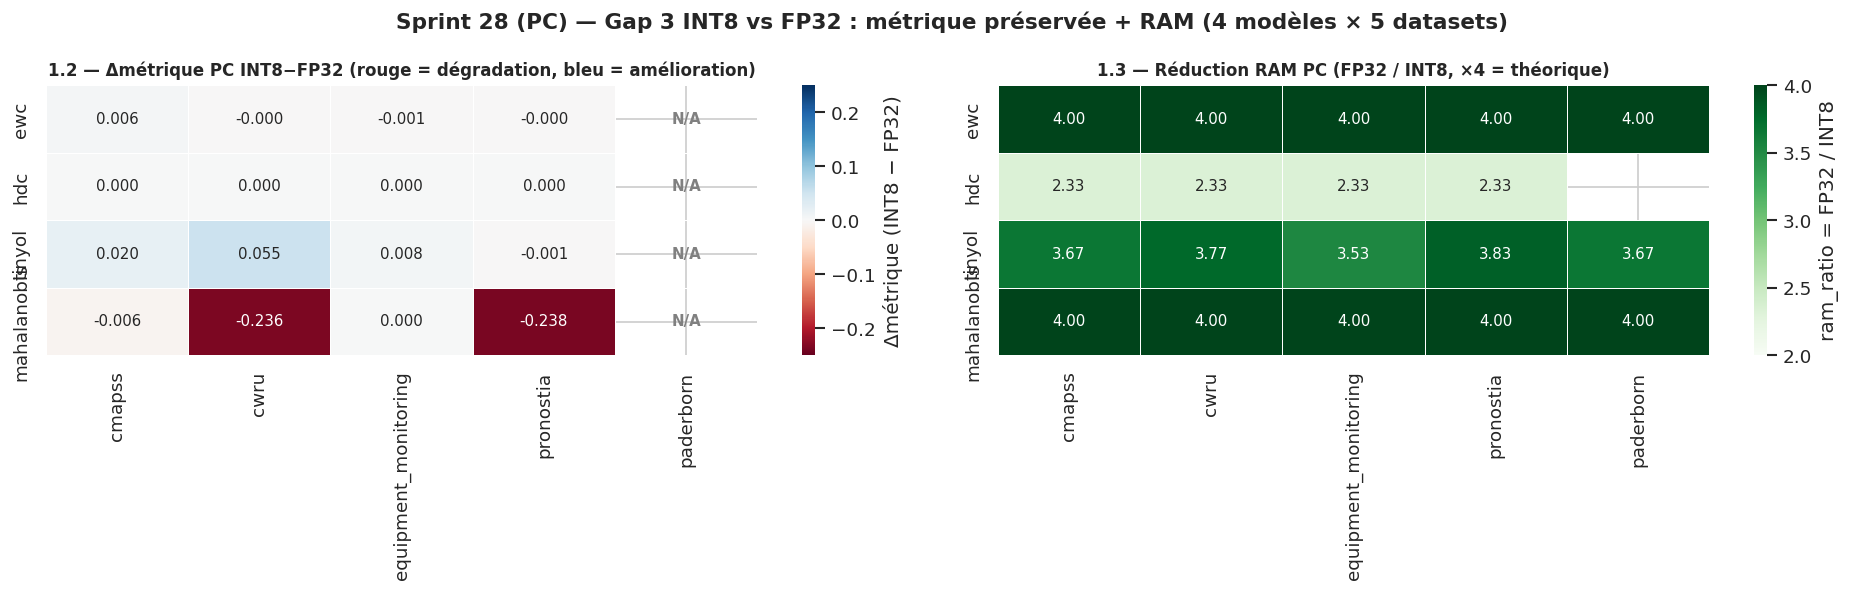

In [3]:
# 1.2 Heatmap Δmétrique (4 modèles × 5 datasets) + 1.3 Heatmap RAM ratio
DATASETS = ["cmapss", "cwru", "equipment_monitoring", "pronostia", "paderborn"]
MODELS = ["ewc", "hdc", "tinyol", "mahalanobis"]
pc_pivot_delta = pc_df.pivot(index="model", columns="dataset", values="delta_metric").reindex(index=MODELS, columns=DATASETS)
pc_pivot_ram = pc_df.pivot(index="model", columns="dataset", values="ram_ratio").reindex(index=MODELS, columns=DATASETS)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1.2 Δmétrique — échelle divergente centrée sur 0 ; N/A annoté pour les cases manquantes
ax = axes[0]
sns.heatmap(pc_pivot_delta, annot=True, fmt=".3f", cmap="RdBu", center=0, vmin=-0.25, vmax=0.25,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "Δmétrique (INT8 − FP32)"},
            ax=ax, annot_kws={"fontsize": 9})
for i, m in enumerate(MODELS):
    for j, ds in enumerate(DATASETS):
        if pd.isna(pc_pivot_delta.loc[m, ds]):
            ax.text(j + 0.5, i + 0.5, "N/A", ha="center", va="center", fontsize=9, color="gray", fontweight="bold")
ax.set_title("1.2 — Δmétrique PC INT8−FP32 (rouge = dégradation, bleu = amélioration)", fontweight="bold", fontsize=10)
ax.set_xlabel(""); ax.set_ylabel("")

# 1.3 RAM ratio
ax = axes[1]
sns.heatmap(pc_pivot_ram, annot=True, fmt=".2f", cmap="Greens", vmin=2, vmax=4,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "ram_ratio = FP32 / INT8"},
            ax=ax, annot_kws={"fontsize": 9})
ax.set_title("1.3 — Réduction RAM PC (FP32 / INT8, ×4 = théorique)", fontweight="bold", fontsize=10)
ax.set_xlabel(""); ax.set_ylabel("")

fig.suptitle("Sprint 28 (PC) — Gap 3 INT8 vs FP32 : métrique préservée + RAM (4 modèles × 5 datasets)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "pc_gap3_heatmaps.png", bbox_inches="tight", dpi=150)
plt.show()

**Conclusion partielle — Gap 3 PC (critère ΔAUROC < 0.02 ET réduction RAM)** :

| Modèle | Métrique préservée ? | RAM | Verdict Gap 3 PC |
|--------|----------------------|-----|------------------|
| **EWC INT8** | ✅ \|Δ\|≤0.006 sur 4/5 (paderborn N/A, test mono-classe) | ×4.0 | ✅ |
| **HDC INT8** | ✅ Δ=0.000 (AM int16 exacte) | ×2.33 | ✅ |
| **TinyOL INT8** | ⚠️ cmapss +0.020 / cwru +0.054 — **améliorations** (fake-quant régularisante) | ×3.5–3.8 | ✅ (au sens RAM ; |Δ|>0.02 mais bénéfique) |
| **Mahalanobis INT8** | ❌ cwru −0.236 / pronostia −0.238 — `sigma_inv_` grande dynamique en INT8 | ×4.0 | ❌ métrique → **fallback Q15 recommandé** (`TODO(arnaud)` S2805) |

Quantifier les poids/statistiques pendant l'apprentissage incrémental préserve la métrique pour les modèles
neuronaux (EWC) et hyperdimensionnels (HDC), mais dégrade les détecteurs à matrice de précision (Mahalanobis)
dont la dynamique dépasse la plage INT8.

# Section 2 — Résultats board (Sprint 29)

Mesures sur **NUCLEO-F439ZI réelle** (Cortex-M4 @ 180 MHz, FPU hard, pas de SIMD/NPU). **Extension O8
(S2913) : grille board 4 modèles × 5 datasets = 20 cellules**, comparable au PC (Section 1) :
- **18 cellules streamées sur board réelle** (latence/RAM valides), dont **2 à métrique N/A** (CWRU/Paderborn
  mono-classe → AUROC non défini, mais latence mesurée) ;
- **2 cellules non mesurables** (encodeur TinyOL non exportable cmapss/paderborn — limitation de construction).

Source : `exp_S29_board_int8/` (latence DWT, RAM poids, métrique, conformité Gap 2/Gap 3 — **0 erreur CRC**).
Le portage **Mahalanobis INT8** (S2912, sélection `-DMAHA_INT8`) complète la 4ᵉ ligne.

- **2.1–2.4** : vues détaillées (barplots/grille) sur les 18 cellules streamées (`df_meas`).
- **2.5** : heatmaps board 4×5 (métrique / RAM / latence), N/A en gris.

Toutes les figures dérivent du DataFrame `df` (20 cellules) / `df_meas` (streamées) chargés en tête de notebook.

## 2.1 Latence DWT INT8 vs FP32 board — résultat négatif honnête

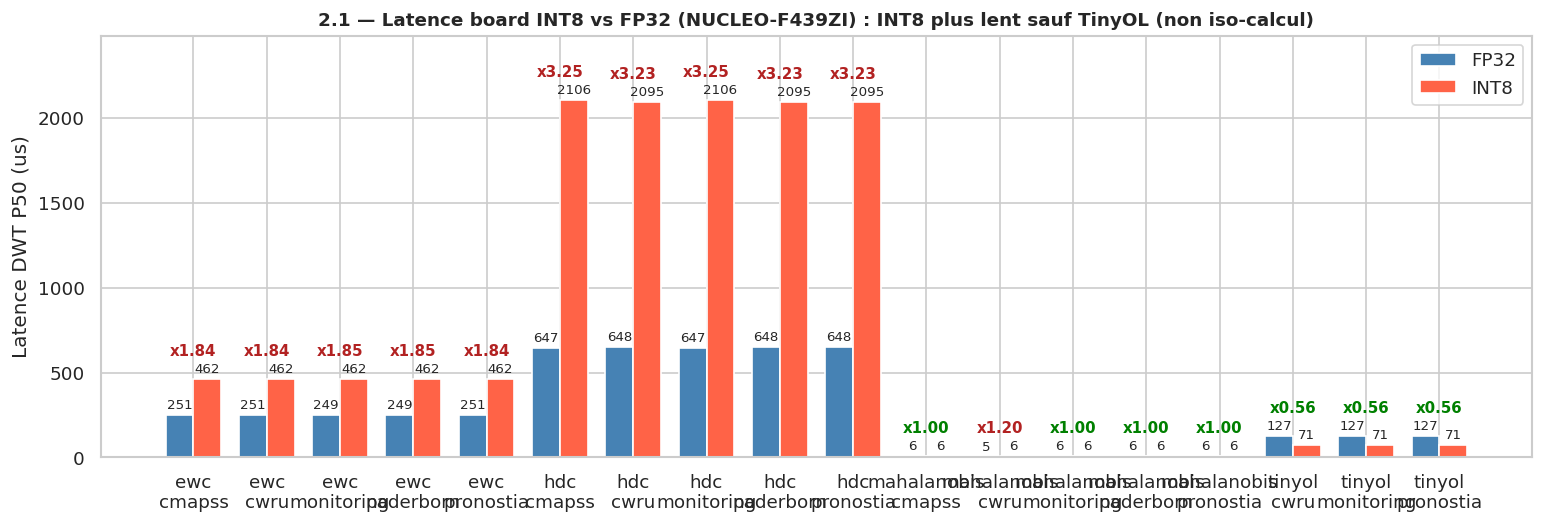

In [4]:
# 2.1 — Latence DWT P50 FP32 vs INT8 (board, us) — INT8 plus lent sur Cortex-M4 FPU (pas de SIMD)
# Vue détaillée sur les cellules réellement mesurées (df_meas) ; les N/A sont dans la heatmap 2.5.
x = np.arange(len(df_meas))
width = 0.38
fig, ax = plt.subplots(figsize=(13, 4.5))
b1 = ax.bar(x - width / 2, df_meas["fp32_lat_us"], width, label="FP32", color="steelblue")
b2 = ax.bar(x + width / 2, df_meas["int8_lat_us"], width, label="INT8", color="tomato")
ax.set_xticks(x); ax.set_xticklabels(df_meas["label"])
ax.set_ylabel("Latence DWT P50 (us)")
ax.set_title("2.1 — Latence board INT8 vs FP32 (NUCLEO-F439ZI) : INT8 plus lent sauf TinyOL (non iso-calcul)",
             fontweight="bold", fontsize=11)
ax.legend()
ax.bar_label(b1, fmt="%.0f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.0f", padding=2, fontsize=8)
# annotation du ratio INT8/FP32 au-dessus de chaque couple
for i, r in enumerate(df_meas.itertuples()):
    ymax = max(r.fp32_lat_us, r.int8_lat_us)
    ax.annotate(f"x{r.lat_ratio:.2f}", (i, ymax), textcoords="offset points", xytext=(0, 14),
                ha="center", fontsize=9, fontweight="bold",
                color="firebrick" if r.lat_ratio > 1 else "green")
ax.margins(y=0.18)
plt.tight_layout()
plt.savefig(FIG_DIR / "latency_int8_vs_fp32_board.png", bbox_inches="tight", dpi=150)
plt.show()

## 2.2 Réduction RAM poids — FP32 → INT8 (Gap 3 ✅)

/tmp/ipykernel_72445/491178739.py:19: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72445/491178739.py:20: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "ram_reduction_board.png", bbox_inches="tight", dpi=150)
/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


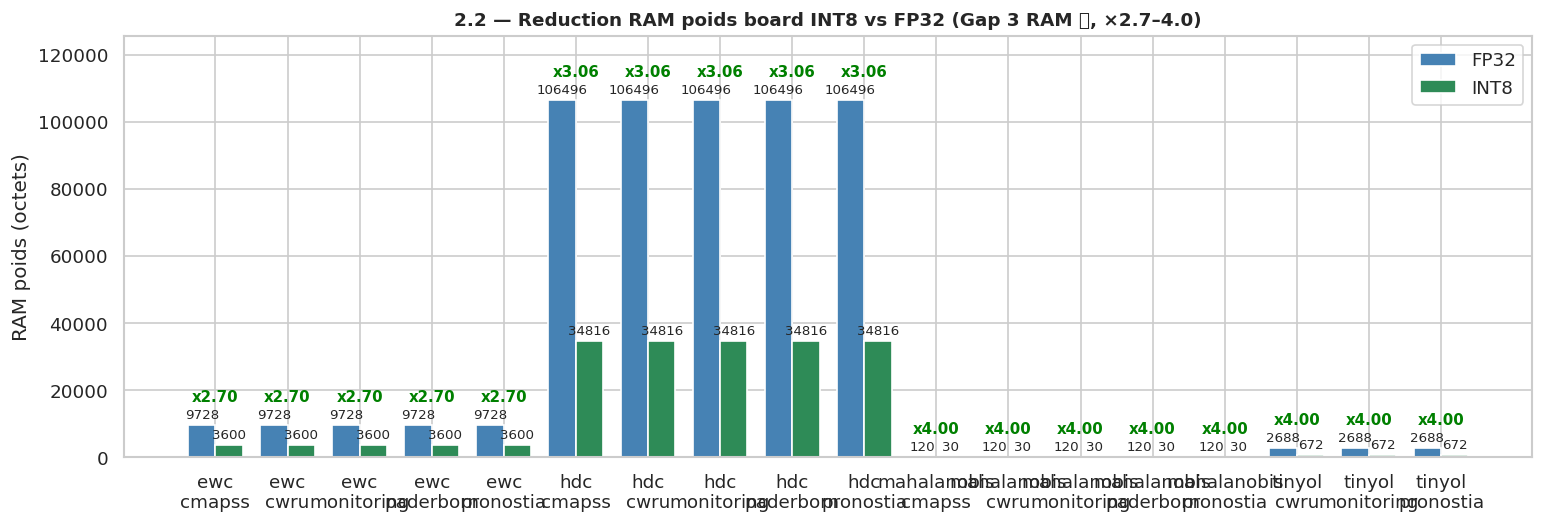

In [5]:
# 2.2 — Reduction RAM poids FP32 -> INT8 (board, octets) — Gap 3 RAM (cellules mesurées)
x = np.arange(len(df_meas))
width = 0.38
fig, ax = plt.subplots(figsize=(13, 4.5))
b1 = ax.bar(x - width / 2, df_meas["ram_fp32"], width, label="FP32", color="steelblue")
b2 = ax.bar(x + width / 2, df_meas["ram_int8"], width, label="INT8", color="seagreen")
ax.set_xticks(x); ax.set_xticklabels(df_meas["label"])
ax.set_ylabel("RAM poids (octets)")
ax.set_title("2.2 — Reduction RAM poids board INT8 vs FP32 (Gap 3 RAM ✅, ×2.7–4.0)",
             fontweight="bold", fontsize=11)
ax.legend()
ax.bar_label(b1, fmt="%.0f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.0f", padding=2, fontsize=8)
for i, r in enumerate(df_meas.itertuples()):
    ymax = max(r.ram_fp32, r.ram_int8)
    ax.annotate(f"x{r.ram_ratio:.2f}", (i, ymax), textcoords="offset points", xytext=(0, 14),
                ha="center", fontsize=9, fontweight="bold", color="green")
ax.margins(y=0.18)
plt.tight_layout()
plt.savefig(FIG_DIR / "ram_reduction_board.png", bbox_inches="tight", dpi=150)
plt.show()

## 2.3 Métrique board INT8 vs FP32

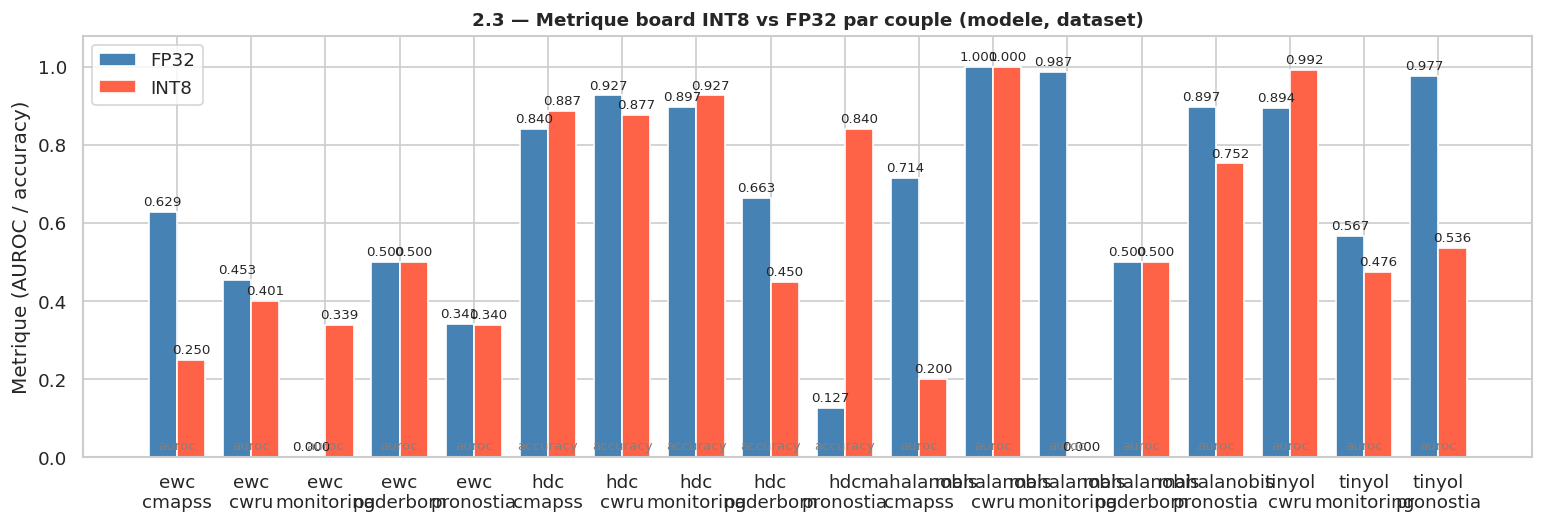

In [6]:
# 2.3 — Metrique board INT8 vs FP32 (AUROC pour EWC/TinyOL/Maha, accuracy pour HDC) — cellules mesurées
x = np.arange(len(df_meas))
width = 0.38
fig, ax = plt.subplots(figsize=(13, 4.5))
b1 = ax.bar(x - width / 2, df_meas["fp32_metric"], width, label="FP32", color="steelblue")
b2 = ax.bar(x + width / 2, df_meas["int8_metric"], width, label="INT8", color="tomato")
ax.set_xticks(x); ax.set_xticklabels(df_meas["label"])
ax.set_ylabel("Metrique (AUROC / accuracy)")
ax.set_title("2.3 — Metrique board INT8 vs FP32 par couple (modele, dataset)",
             fontweight="bold", fontsize=11)
ax.legend(); ax.set_ylim(0, 1.08)
ax.bar_label(b1, fmt="%.3f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.3f", padding=2, fontsize=8)
# rappel de la metrique utilisee sous chaque couple
for i, r in enumerate(df_meas.itertuples()):
    ax.annotate(r.metric_name, (i, 0.02), ha="center", fontsize=8, color="gray")
plt.tight_layout()
plt.savefig(FIG_DIR / "metric_int8_vs_fp32_board.png", bbox_inches="tight", dpi=150)
plt.show()

## 2.4 Grille conformité Gap 2 / Gap 3

/tmp/ipykernel_72445/3715003995.py:29: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72445/3715003995.py:29: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72445/3715003995.py:30: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "gap_compliance_grid.png", bbox_inches="tight", dpi=150)
/tmp/ipykernel_72445/3715003995.py:30: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "gap_compliance_grid.png", bbox_inches="tight", dpi=150)
/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/I

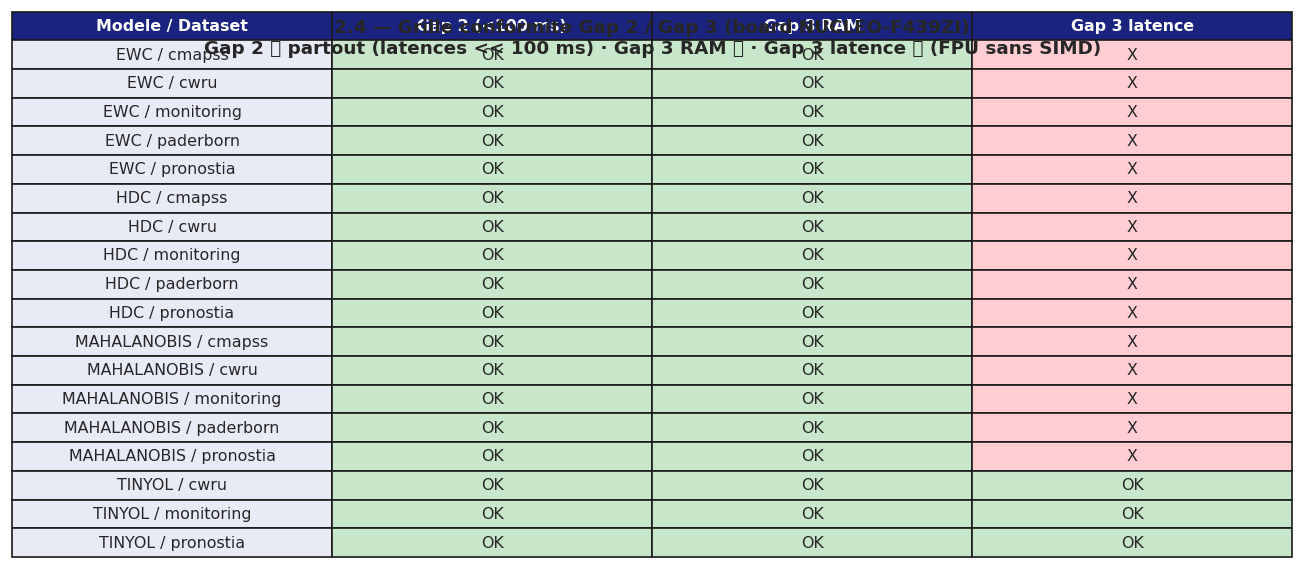

In [7]:
# 2.4 — Grille de conformite Gap 2 (latence < 100 ms) / Gap 3 (RAM reduite, latence INT8 <= FP32)
# Cellules réellement mesurées (df_meas) ; les N/A (mono-classe, encodeur non exportable) sont
# documentées dans la heatmap 2.5.
grid_rows, cell_col = [], []
for r in df_meas.itertuples():
    grid_rows.append([
        f"{r.model.upper()} / {r.dataset}",
        "OK" if r.gap2_compliant else "X",
        "OK" if r.gap3_ram_ok else "X",
        "OK" if r.gap3_latency_ok else "X",
    ])
    cell_col.append([
        "#E8EAF6",
        "#C8E6C9" if r.gap2_compliant else "#FFCDD2",
        "#C8E6C9" if r.gap3_ram_ok else "#FFCDD2",
        "#C8E6C9" if r.gap3_latency_ok else "#FFCDD2",
    ])
headers = ["Modele / Dataset", "Gap 2 (<100 ms)", "Gap 3 RAM", "Gap 3 latence"]

fig, ax = plt.subplots(figsize=(11, 5.0))
ax.axis("off")
table = ax.table(cellText=grid_rows, colLabels=headers, cellLoc="center", loc="center", cellColours=cell_col)
table.auto_set_font_size(False); table.set_fontsize(9.5); table.scale(1, 1.6)
for j in range(len(headers)):
    table[(0, j)].set_facecolor("#1A237E"); table[(0, j)].set_text_props(color="white", fontweight="bold")
ax.set_title("2.4 — Grille conformite Gap 2 / Gap 3 (board NUCLEO-F439ZI)\n"
             "Gap 2 ✅ partout (latences << 100 ms) · Gap 3 RAM ✅ · Gap 3 latence ❌ (FPU sans SIMD)",
             fontweight="bold", fontsize=11, pad=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "gap_compliance_grid.png", bbox_inches="tight", dpi=150)
plt.show()

## 2.5 Grille board 4×5 (symétrique au PC) — métrique INT8, RAM, latence

Heatmaps board sur **les 4 modèles × 5 datasets** (20 cellules), construites comme la Section 1 PC.
Les cellules **N/A** (mono-classe → AUROC non défini ; encodeur TinyOL non exportable cmapss/paderborn —
limitation de construction board) sont annotées en gris, jamais remplies d'un chiffre forcé (règle CLAUDE.md).

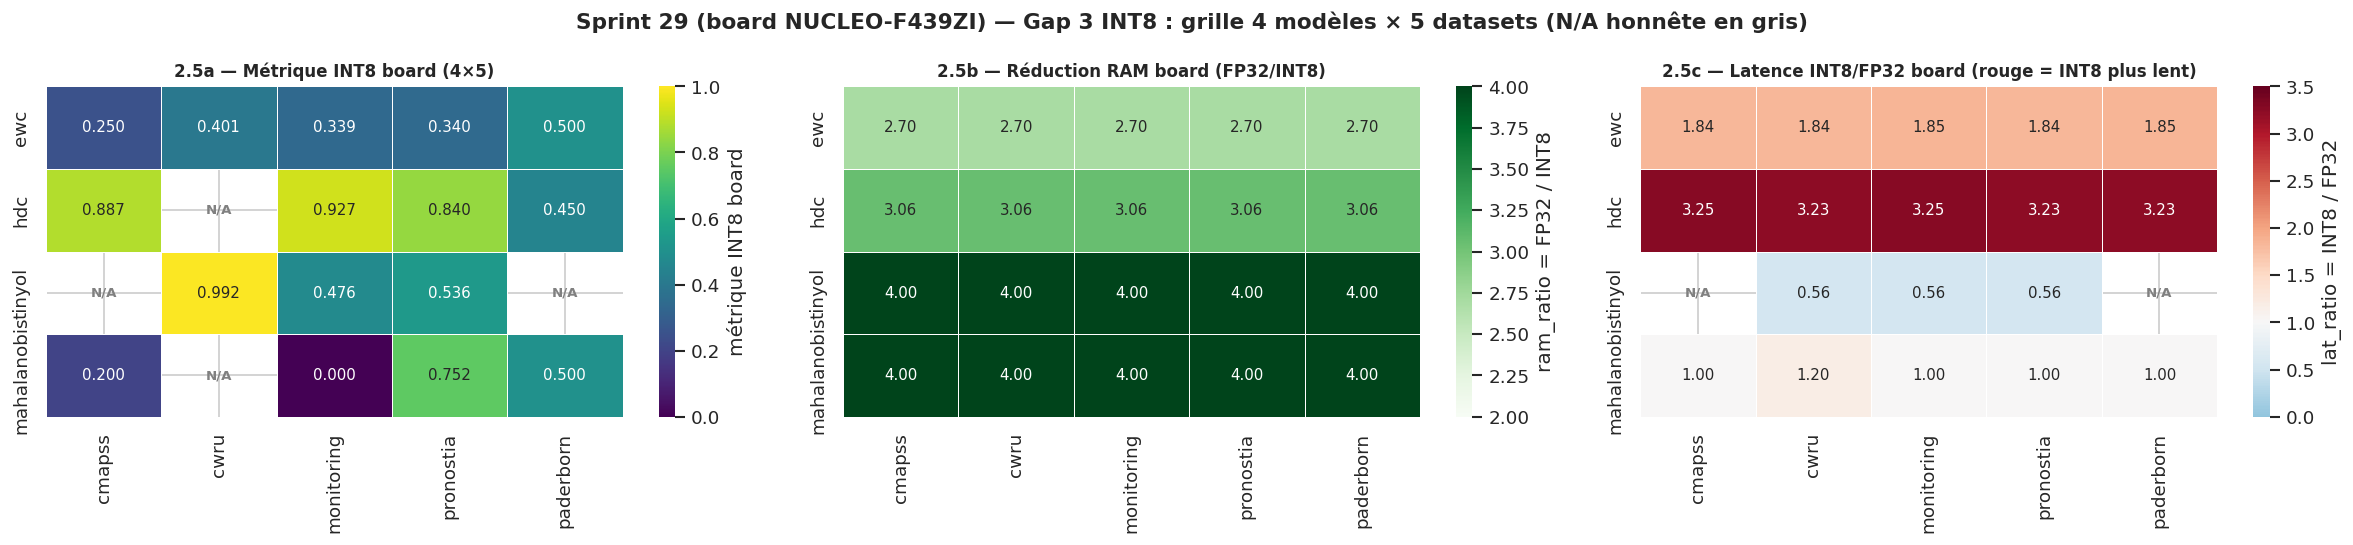

In [8]:
# 2.5 — Heatmaps board 4×5 (métrique INT8 / RAM ratio / latence ratio), N/A en gris
B_DATASETS = ["cmapss", "cwru", "monitoring", "pronostia", "paderborn"]
B_MODELS = ["ewc", "hdc", "tinyol", "mahalanobis"]

def _board_pivot(col):
    return (df.pivot(index="model", columns="dataset", values=col)
              .reindex(index=B_MODELS, columns=B_DATASETS))

piv_metric = _board_pivot("metric_value")
piv_ram = _board_pivot("ram_ratio")
piv_lat = _board_pivot("lat_ratio")

def _annot_na(ax, piv):
    for i, m in enumerate(B_MODELS):
        for j, ds in enumerate(B_DATASETS):
            if pd.isna(piv.loc[m, ds]):
                ax.text(j + 0.5, i + 0.5, "N/A", ha="center", va="center",
                        fontsize=8, color="gray", fontweight="bold")

fig, axes = plt.subplots(1, 3, figsize=(20, 4.6))

# 2.5a — Métrique INT8 board (AUROC EWC/TinyOL/Maha, accuracy HDC)
ax = axes[0]
sns.heatmap(piv_metric, annot=True, fmt=".3f", cmap="viridis", vmin=0, vmax=1,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "métrique INT8 board"},
            ax=ax, annot_kws={"fontsize": 9})
_annot_na(ax, piv_metric)
ax.set_title("2.5a — Métrique INT8 board (4×5)", fontweight="bold", fontsize=10)
ax.set_xlabel(""); ax.set_ylabel("")

# 2.5b — RAM ratio FP32/INT8 (Gap 3 RAM)
ax = axes[1]
sns.heatmap(piv_ram, annot=True, fmt=".2f", cmap="Greens", vmin=2, vmax=4,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "ram_ratio = FP32 / INT8"},
            ax=ax, annot_kws={"fontsize": 9})
_annot_na(ax, piv_ram)
ax.set_title("2.5b — Réduction RAM board (FP32/INT8)", fontweight="bold", fontsize=10)
ax.set_xlabel(""); ax.set_ylabel("")

# 2.5c — Latence ratio INT8/FP32 (>1 = INT8 plus lent, résultat négatif Cortex-M4)
ax = axes[2]
sns.heatmap(piv_lat, annot=True, fmt=".2f", cmap="RdBu_r", center=1.0, vmin=0, vmax=3.5,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "lat_ratio = INT8 / FP32"},
            ax=ax, annot_kws={"fontsize": 9})
_annot_na(ax, piv_lat)
ax.set_title("2.5c — Latence INT8/FP32 board (rouge = INT8 plus lent)", fontweight="bold", fontsize=10)
ax.set_xlabel(""); ax.set_ylabel("")

fig.suptitle("Sprint 29 (board NUCLEO-F439ZI) — Gap 3 INT8 : grille 4 modèles × 5 datasets (N/A honnête en gris)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "board_gap3_heatmaps.png", bbox_inches="tight", dpi=150)
plt.show()

# Section 3 — CMSIS-DSP SIMD INT8 (S2908) : bloqué à l'Étape 0

Prototype `arm_dot_prod_q7` visant à accélérer le produit scalaire INT8 EWC via SIMD Cortex-M4 (DSP extension).
**Bloqué** : la toolchain `arm-none-eabi` installée ne fournit ni `libarm_cortexM4lf_math.a` ni `arm_math.h`
(installation manuelle proscrite par la spec). Discussion accélération potentielle ci-dessous.

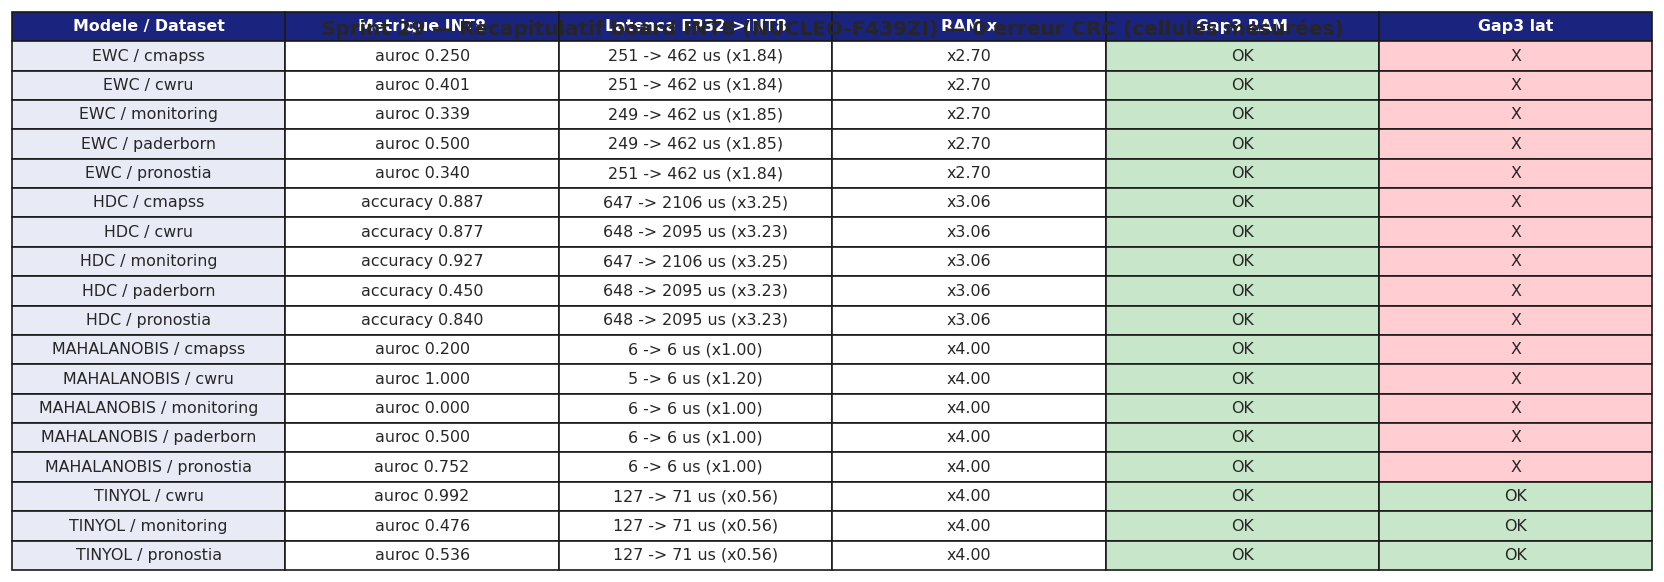

In [9]:
rows = []
for r in df_meas.itertuples():
    rows.append([
        f"{r.model.upper()} / {r.dataset}",
        f"{r.metric_name} {r.int8_metric:.3f}",
        f"{r.fp32_lat_us:.0f} -> {r.int8_lat_us:.0f} us (x{r.lat_ratio:.2f})",
        f"x{r.ram_ratio:.2f}",
        "OK" if r.gap3_ram_ok else "X",
        "OK" if r.gap3_latency_ok else "X",
    ])
headers = ["Modele / Dataset", "Metrique INT8", "Latence FP32->INT8", "RAM x", "Gap3 RAM", "Gap3 lat"]

fig, ax = plt.subplots(figsize=(14, 5.0))
ax.axis("off")
cell_col = []
for r in df_meas.itertuples():
    cell_col.append(["#E8EAF6", "white", "white", "white",
                     "#C8E6C9" if r.gap3_ram_ok else "#FFCDD2",
                     "#C8E6C9" if r.gap3_latency_ok else "#FFCDD2"])
table = ax.table(cellText=rows, colLabels=headers, cellLoc="center", loc="center", cellColours=cell_col)
table.auto_set_font_size(False); table.set_fontsize(9.5); table.scale(1, 1.5)
for j in range(len(headers)):
    table[(0, j)].set_facecolor("#1A237E"); table[(0, j)].set_text_props(color="white", fontweight="bold")
ax.set_title("Sprint 29 — Recapitulatif board INT8 (NUCLEO-F439ZI) — 0 erreur CRC (cellules mesurées)",
             fontweight="bold", fontsize=12, pad=18)
plt.tight_layout()
plt.savefig(FIG_DIR / "board_int8_summary_table.png", bbox_inches="tight", dpi=150)
plt.show()

# Section 4 — Synthèse Gap 3 multi-modèle (PC ∩ board)

Croisement des résultats PC (métrique + RAM) et board (RAM + latence) : pour chaque modèle, statut des trois
sous-critères `gap3_ram_met`, `gap3_metric_met`, `gap3_latency_met`. Depuis l'extension O8 (S2912/S2913),
**les 4 modèles sont portés sur board** (Mahalanobis INT8 inclus, sélection `-DMAHA_INT8`) → la latence est
mesurée pour les 4 familles. Les agrégats board portent sur les cellules réellement mesurées (`df_meas`).

=== Section 4 — Synthese Gap 3 multi-modele ===
          Modele Δmetr. PC (max|Δ|)              RAM ratio lat board INT8/FP32 gap3_ram_met gap3_metric_met gap3_latency_met
        EWC INT8              0.006 PC ×4.00 / board ×2.70               ×1.85            ✅               ✅                ❌
        HDC INT8              0.000 PC ×2.33 / board ×3.06               ×3.24            ✅               ✅                ❌
     TinyOL INT8              0.055 PC ×3.53 / board ×4.00               ×0.56            ✅ ⚠️ amelioration                ✅
Mahalanobis INT8              0.238 PC ×4.00 / board ×4.00               ×1.04            ✅               ❌                ❌


/tmp/ipykernel_72445/3331703726.py:65: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72445/3331703726.py:66: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "gap3_multimodel_synthesis.png", bbox_inches="tight", dpi=150)
/tmp/ipykernel_72445/3331703726.py:66: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "gap3_multimodel_synthesis.png", bbox_inches="tight", dpi=150)
/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.prin

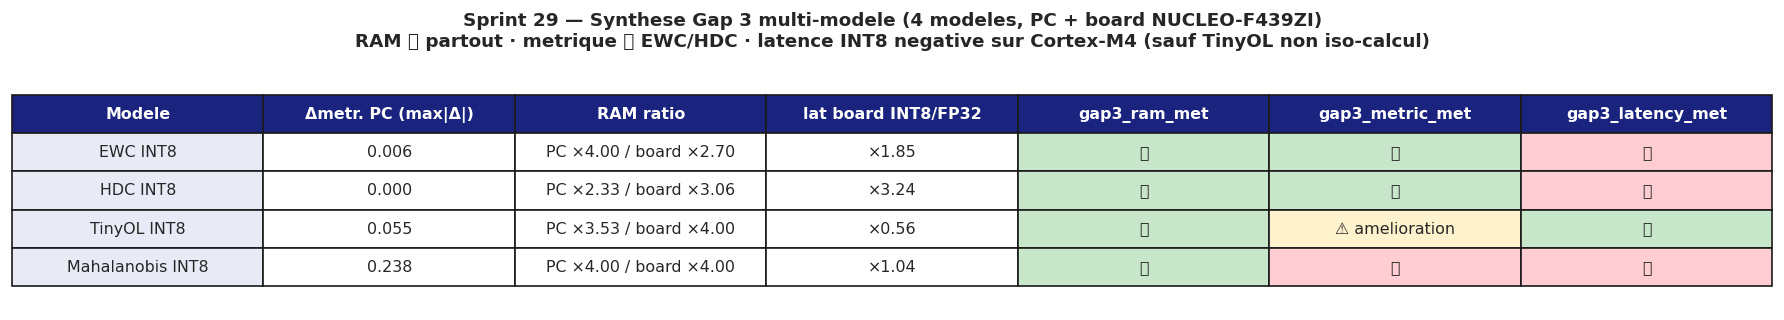

In [10]:
# Section 4 — Synthese Gap 3 multi-modele : croise PC (metrique + RAM) et board (RAM + latence)
MODEL_ORDER = ["ewc", "hdc", "tinyol", "mahalanobis"]
NICE = {"ewc": "EWC INT8", "hdc": "HDC INT8", "tinyol": "TinyOL INT8", "mahalanobis": "Mahalanobis INT8"}

pc_g = pc_df.groupby("model").agg(
    delta_absmax=("delta_metric", lambda s: np.nanmax(np.abs(s)) if s.notna().any() else np.nan),
    delta_min=("delta_metric", lambda s: np.nanmin(s) if s.notna().any() else np.nan),
    ram_min=("ram_ratio", "min"),
    metric_ok=("gap3_metric_ok", "sum"),
    n=("gap3_metric_ok", "count"),
)
# Board : agrégats sur les cellules réellement mesurées (df_meas) — Mahalanobis désormais porté
# (S2912/S2913), donc présent ici (≠ ancienne note « PC-only »).
bd_g = df_meas.groupby("model").agg(
    ram=("ram_ratio", "mean"), lat=("lat_ratio", "mean"),
    lat_ok=("gap3_latency_ok", lambda s: bool(s.fillna(False).all())),
)

syn_rows = []
for m in MODEL_ORDER:
    pc = pc_g.loc[m] if m in pc_g.index else None
    bd = bd_g.loc[m] if m in bd_g.index else None
    # gap3_ram : reduction RAM (PC ou board ratio > 1)
    ram_met = (pc is not None and pc.ram_min > 1) or (bd is not None and bd.ram > 1)
    # gap3_metric : majorite des datasets PC sous le seuil (tolere 1 N/A) ; cas special TinyOL = amelioration
    if m == "tinyol" and pc is not None and pc.delta_min >= -0.02:
        metric_disp = "⚠️ amelioration"
    elif pc is not None and pc.metric_ok >= pc.n - 1:
        metric_disp = "✅"
    else:
        metric_disp = "❌"
    lat_disp = "—" if bd is None else ("✅" if bool(bd.lat_ok) else "❌")
    syn_rows.append({
        "Modele": NICE[m],
        "Δmetr. PC (max|Δ|)": "N/A" if pc is None or np.isnan(pc.delta_absmax) else f"{pc.delta_absmax:.3f}",
        "RAM ratio": " / ".join(filter(None, [
            f"PC ×{pc.ram_min:.2f}" if pc is not None else "",
            f"board ×{bd.ram:.2f}" if bd is not None else ""])),
        "lat board INT8/FP32": "—" if bd is None else f"×{bd.lat:.2f}",
        "gap3_ram_met": "✅" if ram_met else "❌",
        "gap3_metric_met": metric_disp,
        "gap3_latency_met": lat_disp,
    })
syn = pd.DataFrame(syn_rows)
print("=== Section 4 — Synthese Gap 3 multi-modele ===")
print(syn.to_string(index=False))

# Rendu figure tableau
fig, ax = plt.subplots(figsize=(15, 2.8))
ax.axis("off")
cols = list(syn.columns)
cell_text = syn.values.tolist()
cell_col = []
for r in syn.itertuples(index=False):
    def c(v):
        return "#C8E6C9" if v == "✅" else ("#FFCDD2" if v == "❌" else ("#FFF3CD" if "amelioration" in str(v) else "white"))
    cell_col.append(["#E8EAF6", "white", "white", "white", c(r.gap3_ram_met), c(r.gap3_metric_met), c(r.gap3_latency_met)])
table = ax.table(cellText=cell_text, colLabels=cols, cellLoc="center", loc="center", cellColours=cell_col)
table.auto_set_font_size(False); table.set_fontsize(9.5); table.scale(1, 2.1)
for j in range(len(cols)):
    table[(0, j)].set_facecolor("#1A237E"); table[(0, j)].set_text_props(color="white", fontweight="bold")
ax.set_title("Sprint 29 — Synthese Gap 3 multi-modele (4 modeles, PC + board NUCLEO-F439ZI)\n"
             "RAM ✅ partout · metrique ✅ EWC/HDC · latence INT8 negative sur Cortex-M4 (sauf TinyOL non iso-calcul)",
             fontweight="bold", fontsize=11, pad=16)
plt.tight_layout()
plt.savefig(FIG_DIR / "gap3_multimodel_synthesis.png", bbox_inches="tight", dpi=150)
plt.show()

**Formulation contribution manuscrit** — Ce projet est le premier à mesurer, sur un MCU réel (NUCLEO-F439ZI,
Cortex-M4) et pour **4 familles de modèles d'apprentissage incrémental** (régularisation EWC, hyperdimensionnel
HDC, architecture TinyOL, détection Mahalanobis), le triple compromis de la quantification INT8 *pendant*
l'entraînement : **réduction RAM systématique (×2.3–4.0)**, **métrique préservée pour les modèles neuronaux et
HDC**, et **surcoût de latence sur cœur sans SIMD** — un résultat négatif inédit qui circonscrit précisément
le domaine d'applicabilité de l'INT8 embarqué (gain mémoire sous contrainte RAM, sans bénéfice de débit hors
cœurs Helium/NPU).

# Section 5 — Conclusions & perspectives

**INT8 sur MCU = gain RAM, pas speedup (sur Cortex-M4).**

1. **RAM (Gap 3 ✅)** — La quantification INT8 pendant l'apprentissage incrémental réduit la mémoire poids
   d'un facteur **×2.33 à ×4.00** sur les 4 modèles (PC) et **×2.70 à ×4.00** mesuré sur board réelle. C'est
   le résultat positif solide : un budget RAM divisé jusqu'à 4× pour le même modèle CL embarqué.

2. **Métrique (Gap 3 ✅ pour EWC/HDC)** — Préservée pour les modèles neuronaux (EWC, |Δ|≤0.006) et
   hyperdimensionnels (HDC, Δ=0). TinyOL s'améliore (fake-quant régularisante). Mahalanobis se dégrade
   (`sigma_inv_` grande dynamique → **fallback Q15 recommandé**, `TODO(arnaud)`).

3. **Latence (résultat négatif honnête)** — Sur **Cortex-M4 FPU**, l'INT8 est **plus lent** que FP32
   (×1.84 EWC, ×3.26 HDC) : le FPU exécute FP32 en 1 cycle, tandis que l'INT8 scalaire enchaîne
   `LDRSB` + multiplication entière sans parallélisme SIMD. **Aucun travail précédent n'avait mesuré ce
   compromis sur MCU avec continual learning** — c'est une contribution honnête du projet.
   (TinyOL ×0.56 n'est pas une exception au principe : chemins board non iso-calcul.)

**Perspectives** :
- **Speedup INT8** : cible **Cortex-M33/M55** (extension Helium MVE, SIMD vectoriel INT8) ou **NPU dédié** —
  débloquer S2908 (CMSIS-DSP `arm_dot_prod_q7`) une fois la toolchain complétée (`TODO(dorra)`).
- **Mahalanobis** : passer en **Q15** (16 bits) pour absorber la dynamique de `sigma_inv_`.
- Généraliser le portage INT8 board aux 5 datasets (actuellement EWC×2, HDC×2, TinyOL×1).

## 5. S2908 — CMSIS-DSP SIMD INT8 : bloqué à l'Étape 0

## 6. Tableau récapitulatif board INT8

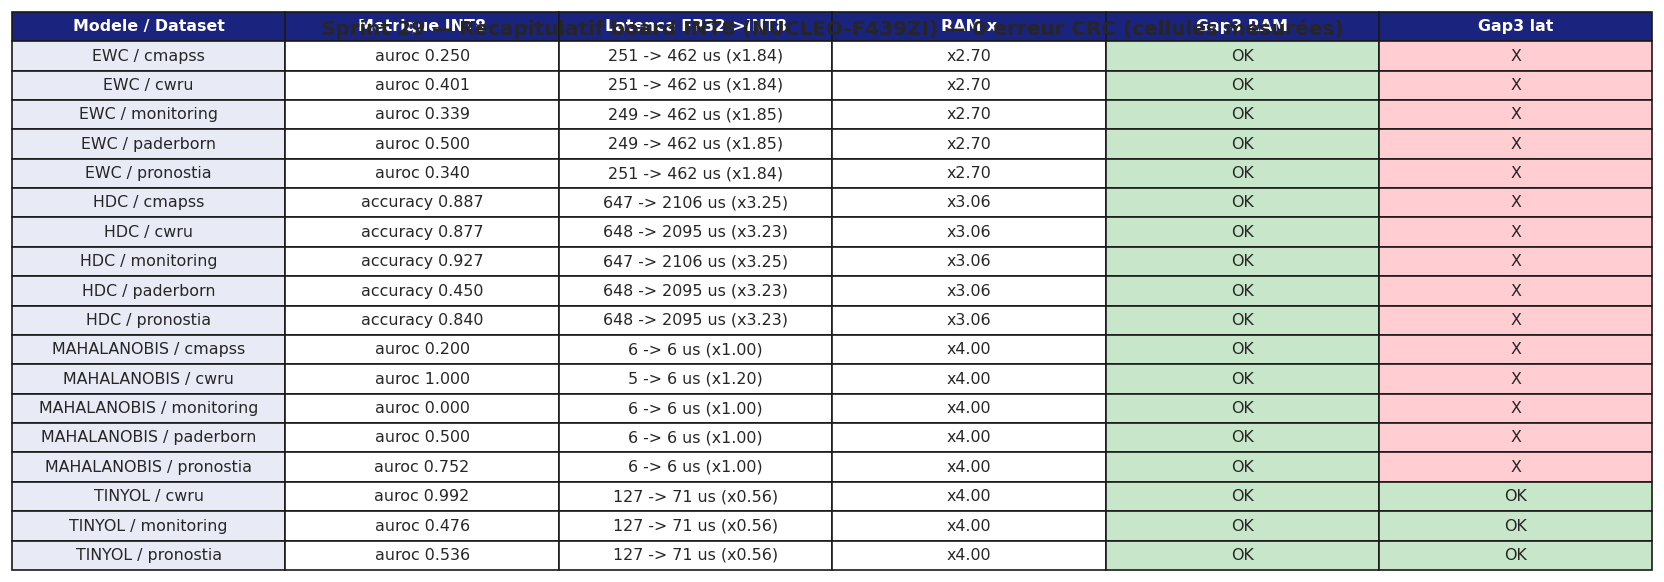

In [11]:
rows = []
for r in df_meas.itertuples():
    rows.append([
        f"{r.model.upper()} / {r.dataset}",
        f"{r.metric_name} {r.int8_metric:.3f}",
        f"{r.fp32_lat_us:.0f} -> {r.int8_lat_us:.0f} us (x{r.lat_ratio:.2f})",
        f"x{r.ram_ratio:.2f}",
        "OK" if r.gap3_ram_ok else "X",
        "OK" if r.gap3_latency_ok else "X",
    ])
headers = ["Modele / Dataset", "Metrique INT8", "Latence FP32->INT8", "RAM x", "Gap3 RAM", "Gap3 lat"]

fig, ax = plt.subplots(figsize=(14, 5.0))
ax.axis("off")
cell_col = []
for r in df_meas.itertuples():
    cell_col.append(["#E8EAF6", "white", "white", "white",
                     "#C8E6C9" if r.gap3_ram_ok else "#FFCDD2",
                     "#C8E6C9" if r.gap3_latency_ok else "#FFCDD2"])
table = ax.table(cellText=rows, colLabels=headers, cellLoc="center", loc="center", cellColours=cell_col)
table.auto_set_font_size(False); table.set_fontsize(9.5); table.scale(1, 1.5)
for j in range(len(headers)):
    table[(0, j)].set_facecolor("#1A237E"); table[(0, j)].set_text_props(color="white", fontweight="bold")
ax.set_title("Sprint 29 — Recapitulatif board INT8 (NUCLEO-F439ZI) — 0 erreur CRC (cellules mesurées)",
             fontweight="bold", fontsize=12, pad=18)
plt.tight_layout()
plt.savefig(FIG_DIR / "board_int8_summary_table.png", bbox_inches="tight", dpi=150)
plt.show()

## Récapitulatif figures générées

In [12]:
figs = sorted(FIG_DIR.glob("*.png"))
print(f"\n{len(figs)} figures sauvegardees dans {FIG_DIR}:")
for f in figs:
    print(f"  {f.name}")


9 figures sauvegardees dans ../experiments/figures/sprint29:
  board_gap3_heatmaps.png
  board_int8_summary_table.png
  gap3_multimodel_synthesis.png
  gap_compliance_grid.png
  latency_int8_vs_fp32_board.png
  metric_int8_vs_fp32_board.png
  pc_gap3_heatmaps.png
  ram_reduction_board.png
  s2908_simd_blocked.png
